# Simple Linear Regression: Housing Data

## Import Necessary Libaries
The code below imports all necessary libraries for the task.

In [1]:
import matplotlib

import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model, metrics
from sklearn.model_selection import train_test_split
import pandas as pd

## Load Data
The code below loads the dataset from a CSV file into a pandas DataFrame.

In [2]:
# Load dataset -- https://drive.google.com/file/d/19IUeHxBI6hscqxe4UlAvXVDyOLJc4WYc/view?usp=drive_link
df = pd.read_csv("https://drive.google.com/uc?export=download&id=19IUeHxBI6hscqxe4UlAvXVDyOLJc4WYc")

## Inspect Data - Head
The code below displays the first 5 rows of the DataFrame to inspect the data.

In [3]:
df.head()

,rownames,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,1,42000,5850,3,1,2,yes,no,yes,no,no,1,no
1,2,38500,4000,2,1,1,yes,no,no,no,no,0,no
2,3,49500,3060,3,1,1,yes,no,no,no,no,0,no
3,4,60500,6650,3,1,2,yes,yes,no,no,no,0,no
4,5,61000,6360,2,1,1,yes,no,no,no,no,0,no


## Inspect Data - Tail
The code below displays the last 5 rows of the DataFrame to inspect the data.

In [4]:
df.tail(1)

,rownames,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
545,546,105000,6000,3,1,2,yes,no,no,no,yes,1,no


## Descriptive Statistics - Numerical
The code below provides descriptive statistics of the numerical columns in the DataFrame.

In [5]:
df.describe()

,rownames,price,lotsize,bedrooms,bathrms,stories,garagepl
count,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000
mean,273.500000,68121.597070,5150.265568,2.965201,1.285714,1.807692,0.692308
std,157.760895,26702.670926,2168.158725,0.737388,0.502158,0.868203,0.861307
min,1.000000,25000.000000,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,137.250000,49125.000000,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,273.500000,62000.000000,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,409.750000,82000.000000,6360.000000,3.000000,2.000000,2.000000,1.000000
max,546.000000,190000.000000,16200.000000,6.000000,4.000000,4.000000,3.000000


## Descriptive Statistics - All
The code below provides descriptive statistics of all columns in the DataFrame, including categorical ones.

In [6]:
summary = df.describe(include='all')
print(summary)

          rownames          price       lotsize    bedrooms     bathrms  \
count   546.000000     546.000000    546.000000  546.000000  546.000000   
unique         NaN            NaN           NaN         NaN         NaN   
top            NaN            NaN           NaN         NaN         NaN   
freq           NaN            NaN           NaN         NaN         NaN   
mean    273.500000   68121.597070   5150.265568    2.965201    1.285714   
std     157.760895   26702.670926   2168.158725    0.737388    0.502158   
min       1.000000   25000.000000   1650.000000    1.000000    1.000000   
25%     137.250000   49125.000000   3600.000000    2.000000    1.000000   
50%     273.500000   62000.000000   4600.000000    3.000000    1.000000   
75%     409.750000   82000.000000   6360.000000    3.000000    2.000000   
max     546.000000  190000.000000  16200.000000    6.000000    4.000000   

           stories driveway recroom fullbase gashw airco    garagepl prefarea  
count   546.000000 

## Data Information
The code below displays information about the DataFrame, including the data types and non-null counts of each column.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546 entries, 0 to 545
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   rownames  546 non-null    int64 
 1   price     546 non-null    int64 
 2   lotsize   546 non-null    int64 
 3   bedrooms  546 non-null    int64 
 4   bathrms   546 non-null    int64 
 5   stories   546 non-null    int64 
 6   driveway  546 non-null    object
 7   recroom   546 non-null    object
 8   fullbase  546 non-null    object
 9   gashw     546 non-null    object
 10  airco     546 non-null    object
 11  garagepl  546 non-null    int64 
 12  prefarea  546 non-null    object
dtypes: int64(7), object(6)
memory usage: 55.6+ KB


## Column Names
The code below displays the column names of the DataFrame.

In [8]:
df.columns

Index(['rownames', 'price', 'lotsize', 'bedrooms', 'bathrms', 'stories',
       'driveway', 'recroom', 'fullbase', 'gashw', 'airco', 'garagepl',
       'prefarea'],
      dtype='object')

## Feature and Target Variable Extraction
The code below extracts the 'price' column as the target variable (Y) and the 'lotsize' column as the feature (X).

In [9]:
# Extract features and target variable
Y = df['price']
X = df['lotsize']

## Reshape Data
The code below reshapes the feature and target variable arrays for compatibility with scikit-learn, which expects a 2D array for features.

In [10]:
X

,lotsize
0,5850
1,4000
2,3060
3,6650
4,6360
...,...
541,4800
542,6000
543,6000
544,6000


The feature (X) and target (Y) variables are reshaped using `.to_numpy().reshape(-1, 1)` because scikit-learn models expect the input data to be in a 2D array format, where each row represents a sample and each column represents a feature. Since we are currently using a single feature ('lotsize'), the data needs to be reshaped from a 1D array (a single column) to a 2D array with one column.

In [11]:
# Reshape for compatibility with scikit-learn
X = X.to_numpy().reshape(len(X), 1)
Y = Y.to_numpy().reshape(len(Y), 1)

In [12]:
X[:10]

array([[ 5850],
       [ 4000],
       [ 3060],
       [ 6650],
       [ 6360],
       [ 4160],
       [ 3880],
       [ 4160],
       [ 4800],
       [ 5500],
       [ 7200],
       [ 3000],
       [ 1700],
       [ 2880],
       [ 3600],
       [ 3185],
       [ 3300],
       [ 5200],
       [ 3450],
       [ 3986],
       [ 4785],
       [ 4510],
       [ 4000],
       [ 3934],
       [ 4960],
       [ 3000],
       [ 3800],
       [ 4960],
       [ 3000],
       [ 4500],
       [ 3500],
       [ 3500],
       [ 4000],
       [ 4500],
       [ 6360],
       [ 4500],
       [ 4032],
       [ 5170],
       [ 5400],
       [ 3150],
       [ 3745],
       [ 4520],
       [ 4640],
       [ 8580],
       [ 2000],
       [ 2160],
       [ 3040],
       [ 3090],
       [ 4960],
       [ 3350],
       [ 5300],
       [ 4100],
       [ 9166],
       [ 4040],
       [ 3630],
       [ 3620],
       [ 2400],
       [ 7260],
       [ 4400],
       [ 2400],
       [ 4120],
       [ 4750],
       [

## Split Data (Manual)
The code below splits the data into training and testing sets.

In [13]:
# Split data into training and testing sets
X_train = X[:-250]
X_test = X[-250:]
Y_train = Y[:-250]
Y_test = Y[-250:]

## Split Data (train_test_split)
The code below splits the data into training and testing sets using `train_test_split` from scikit-learn, with a test size of 20% and a fixed random state for reproducibility.

In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [15]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((436, 1), (110, 1), (436, 1), (110, 1))

## Plot Training Data
The code below plots the training data as a scatter plot to visualize the relationship between 'lotsize' and 'price'.

([], [])

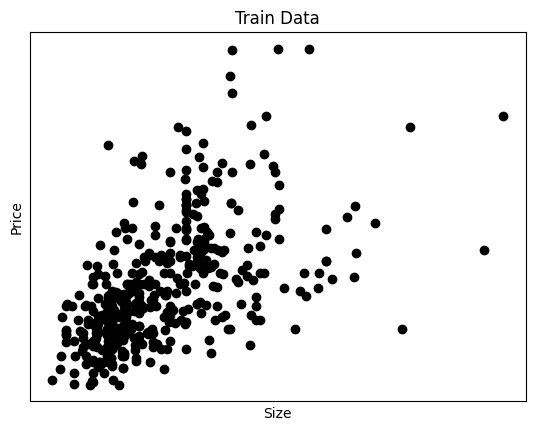

In [16]:
# Plot the train data
plt.scatter(X_train, Y_train, color='black')
plt.title('Train Data')
plt.xlabel('Size')
plt.ylabel('Price')
plt.xticks(())
plt.yticks(())

## Plot Testing Data
The code below plots the testing data as a scatter plot to visualize the relationship between 'lotsize' and 'price'.

([], [])

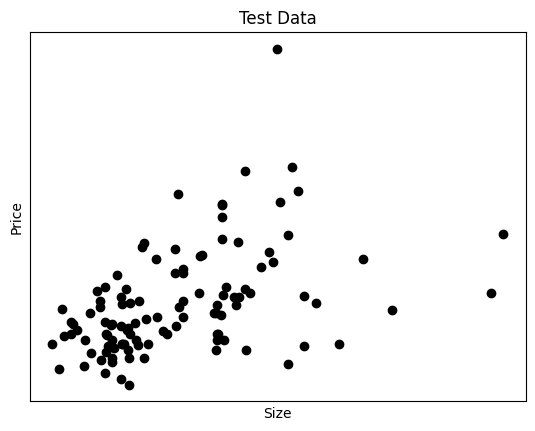

In [17]:
# Plot the test data
plt.scatter(X_test, Y_test, color='black')
plt.title('Test Data')
plt.xlabel('Size')
plt.ylabel('Price')
plt.xticks(())
plt.yticks(())

## Train Model
The code below trains a linear regression model using the training data.

In [18]:
# Train linear regression model
regr = linear_model.LinearRegression()


In [20]:
# print(regr.coef_)
# print(regr.intercept_)

AttributeError: 'LinearRegression' object has no attribute 'coef_'

In [21]:
regr.fit(X_train, Y_train)

LinearRegression()

In [22]:
print(regr.coef_)
print(regr.intercept_)

[[6.88540888]]
[33003.3621689]


## Make Predictions
The code below makes predictions on the test data using the trained linear regression model.

In [23]:
predict = regr.predict(X_test)

In [27]:
X_test[:5]

array([[5000],
       [3180],
       [6600],
       [6060],
       [5985]])

In [28]:
Y_test[:5]

array([[ 80000],
       [ 47000],
       [130000],
       [ 47000],
       [ 59000]])

In [26]:
predict[:5]

array([[67430.4065689],
       [54898.9624073],
       [78447.0607769],
       [74728.9399817],
       [74212.5343157]])

## Plot Predictions
The code below plots the test data and the linear regression line representing the model's predictions.

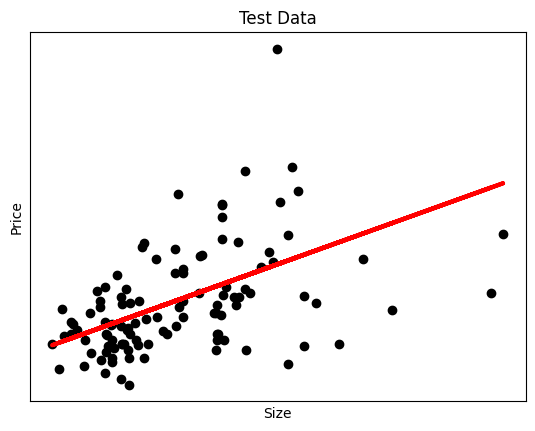

In [24]:
# Plot predictions
plt.scatter(X_test, Y_test, color='black')
plt.title('Test Data')
plt.xlabel('Size')
plt.ylabel('Price')
plt.xticks(())
plt.yticks(())
plt.plot(X_test, regr.predict(X_test), color='red', linewidth=3)
plt.show()

Plot Training

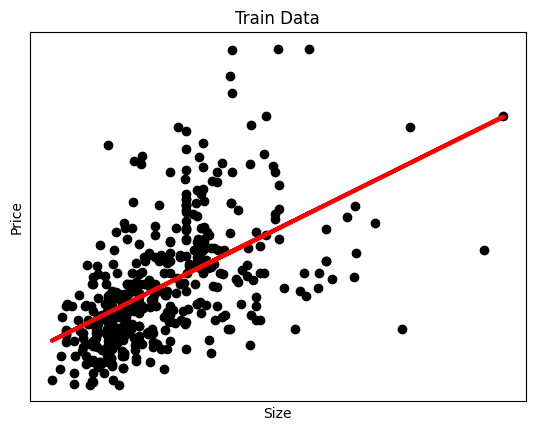

In [25]:
# Plot predictions
plt.scatter(X_train, Y_train, color='black')
plt.title('Train Data')
plt.xlabel('Size')
plt.ylabel('Price')
plt.xticks(())
plt.yticks(())
plt.plot(X_train, regr.predict(X_train), color='red', linewidth=3)
plt.show()

In [29]:
pdf = pd.DataFrame()
pdf['X_test'] = X_test.flatten()
pdf['Y_test'] = Y_test.flatten()
pdf['Y_pred'] = regr.predict(X_test).flatten()
pdf

,X_test,Y_test,Y_pred
0,5000,80000,67430.406569
1,3180,47000,54898.962407
2,6600,130000,78447.060777
3,6060,47000,74728.939982
4,5985,59000,74212.534316
...,...,...,...
105,6420,95000,77207.687178
106,3150,54500,54692.400141
107,3630,38000,57997.396403
108,2610,60000,50974.279346


In [30]:
pdf['Diff_Squared'] = (pdf['Y_test'] - pdf['Y_pred'])**2
pdf

,X_test,Y_test,Y_pred,Diff_Squared
0,5000,80000,67430.406569,1.579947e+08
1,3180,47000,54898.962407,6.239361e+07
2,6600,130000,78447.060777,2.657706e+09
3,6060,47000,74728.939982,7.688941e+08
4,5985,59000,74212.534316,2.314212e+08
...,...,...,...,...
105,6420,95000,77207.687178,3.165664e+08
106,3150,54500,54692.400141,3.701781e+04
107,3630,38000,57997.396403,3.998959e+08
108,2610,60000,50974.279346,8.146363e+07


In [32]:
y_mean = pdf['Y_test'].mean()
y_mean

np.float64(64886.818181818184)

In [34]:
pdf['squared_totals'] = (pdf['Y_test'] - y_mean)**2
pdf

,X_test,Y_test,Y_pred,Diff_Squared,squared_totals
0,5000,80000,67430.406569,1.579947e+08,2.284083e+08
1,3180,47000,54898.962407,6.239361e+07,3.199383e+08
2,6600,130000,78447.060777,2.657706e+09,4.239726e+09
3,6060,47000,74728.939982,7.688941e+08,3.199383e+08
4,5985,59000,74212.534316,2.314212e+08,3.465463e+07
...,...,...,...,...,...
105,6420,95000,77207.687178,3.165664e+08,9.068037e+08
106,3150,54500,54692.400141,3.701781e+04,1.078860e+08
107,3630,38000,57997.396403,3.998959e+08,7.229010e+08
108,2610,60000,50974.279346,8.146363e+07,2.388099e+07


## Calculate RMSE
The code below calculates the Root Mean Squared Error (RMSE) of the model's predictions on the test data.

In [33]:
rmse = np.sqrt(np.mean((predict - Y_test)**2))
rmse

np.float64(23322.118783664337)

## Calculate R-squared
The code below calculates the R-squared score of the model on the test data, which represents the proportion of the variance in the dependent variable that is predictable from the independent variable.

In [31]:
r2 = regr.score(X_test, Y_test)
r2

0.18583856088525563

y_mean = pdf.

## Model Performance and Next Steps

Based on the evaluation metrics:

*   **RMSE (Root Mean Squared Error):** `np.float64(23322.118783664337)`
*   **R-squared:** `0.18583856088525563`

The RMSE indicates that, on average, the model's predictions are off by approximately $23,322. This value should be interpreted in the context of the price range of the houses in the dataset. The R-squared value of approximately 0.186 suggests that only about 18.6% of the variance in the house prices can be explained by the 'lotsize' feature alone. This indicates that 'lotsize' is not a strong predictor of house price in this dataset, and the simple linear regression model is not performing very well.

To improve the prediction performance, consider the following steps:

1.  **Feature Engineering:** Explore other features in the dataset that might have a stronger correlation with 'price'. Consider including multiple features in a multiple linear regression model.
2.  **Handling Categorical Features:** Convert the categorical features (like 'driveway', 'recroom', etc.) into numerical format using techniques like one-hot encoding.
3.  **Feature Selection:** Use techniques to select the most relevant features for predicting house price.
4.  **More Complex Models:** If a linear model is not sufficient, explore other regression algorithms such as polynomial regression, decision trees, random forests, or gradient boosting.
5.  **Data Scaling:** Scale numerical features to have a similar range, which can improve the performance of some models.
6.  **Outlier Detection and Handling:** Identify and handle outliers in the data that might be skewing the model.